# Ugail-Howard Index for Consciousness Dynamics  — Colab

Includes requested tweaks and optional refinement toggles.


In [56]:
# ============================================================================
#####################################################################
# Ugail-Howard Index for Consciousness Dynamics ##
####################################################################


In [57]:
######
#
# Ugail-Howard Index for Consciousness Dynamics

# This notebook implements a mathematical framework for measuring consciousness from brain signals (EEG).
# It combines three fundamental aspects of neural dynamics into a single metric (Ψ) that quantifies the "quality" of consciousness.

## What does this measure?

#  Ψ captures consciousness through three key dimensions:
#
# 1. **Hierarchical Integration (H_eff)** - How brain rhythms are organised across timescales
# 2. **Organized Complexity (D)** - Phase-amplitude coupling and information richness
# 3. **Metastability (M)** - The brain's dynamic flexibility while maintaining coherence
#
# **Higher Ψ scores** indicate richer, more organised consciousness dynamics (waking consciousness)
# **Lower Ψ scores** suggest reduced consciousness (deep sleep, anaesthesia, disorders)
#
# ---
## Who is this for?
#
# - **Researchers** studying consciousness, anaesthesia, sleep, or neurological disorders
# - **Neuroscientists** analysing EEG or electrophysiological recordings
# - **Students** learning computational approaches to consciousness measurement
# - **Data scientists** interested in advanced brain signal analysis
########


In [58]:

# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import random

from scipy.signal import butter, filtfilt, hilbert
from sklearn.metrics import roc_auc_score, roc_curve

# ---------------------------------------------------------------------
# GLOBAL CONFIG, RANDOM SEED, AND PLOTTING STYLE
# ---------------------------------------------------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

CFG = {
    "fs": 250,
    "max_channels": 32,
    "max_timepoints": 5000,
}

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "legend.frameon": False,
    }
)


def format_label(key: str) -> str:
    """
    Convert internal identifiers like 'no_pac' or 'non_conscious'
    into publication-style labels like 'No PAC' or 'Non-conscious'.
    """
    special_map = {
        "pac": "PAC",   # keep PAC uppercase
    }

    words = key.replace("_", " ").split()
    pretty_words = []
    for w in words:
        lw = w.lower()
        if lw in special_map:
            pretty_words.append(special_map[lw])
        elif w.isupper():
            pretty_words.append(w)
        else:
            pretty_words.append(w.capitalize())
    return " ".join(pretty_words)


In [59]:

# ---------------------------------------------------------------------
# BASIC SIGNAL UTILITIES
# ---------------------------------------------------------------------
def bandpass_filter(data, fs, low, high, order=4):
    """Zero-phase bandpass filter along last axis."""
    nyq = fs / 2.0
    lowc, highc = low / nyq, high / nyq
    b, a = butter(order, [lowc, highc], btype="band")
    return filtfilt(b, a, data, axis=-1)


def generate_pink_noise(n_channels, n_samples):
    """
    Approximate pink (1/f) noise by cumulative sum of white noise.
    Returns shape (n_channels, n_samples).
    """
    white = np.random.randn(n_channels, n_samples)
    pink = np.cumsum(white, axis=-1)
    pink -= pink.mean(axis=-1, keepdims=True)
    pink /= pink.std(axis=-1, keepdims=True) + 1e-9
    return pink



In [60]:

# ---------------------------------------------------------------------
# CORE METRIC UTILITIES (DFA, LZ, MI)
# ---------------------------------------------------------------------


def dfa_hurst(x, min_win=16, max_win=None, n_win=10):
    """
    Simple DFA-based Hurst exponent estimate for a 1D signal x.
    """
    x = np.asarray(x)
    N = x.size
    if max_win is None:
        max_win = N // 4

    y = np.cumsum(x - x.mean())
    s_vals = np.unique(
        np.logspace(np.log10(min_win), np.log10(max_win), n_win, dtype=int)
    )
    F = []
    for s in s_vals:
        if s < 4:
            continue
        n_segments = N // s
        if n_segments < 2:
            continue
        rms = []
        for i in range(n_segments):
            seg = y[i * s : (i + 1) * s]
            t = np.arange(s)
            p = np.polyfit(t, seg, 1)
            trend = np.polyval(p, t)
            detrended = seg - trend
            rms.append(np.sqrt(np.mean(detrended**2)))
        if rms:
            F.append(np.mean(rms))
    F = np.array(F)
    if len(F) < 2:
        return 0.5

    s_use = s_vals[: len(F)]
    coeffs = np.polyfit(np.log(s_use), np.log(F), 1)
    H = coeffs[0]
    return float(H)


def lempel_ziv_complexity(binary_seq):
    """
    Lempel–Ziv complexity for a 1D binary sequence (0/1).
    """
    s = "".join(str(int(b)) for b in binary_seq)
    i, c, l = 0, 1, 1
    n = len(s)
    while True:
        if i + l > n:
            c += 1
            break
        sub = s[i : i + l]
        if sub in s[:i]:
            l += 1
        else:
            i += l
            c += 1
            l = 1
        if i + l > n:
            break
    return c / n


def mutual_information_phase_amp(phase, amp, n_bins=12):
    """
    Mutual information between phase (continuous angle) and amplitude (positive).
    Discretises both into n_bins.
    """
    phase = np.asarray(phase)
    amp = np.asarray(amp)

    phase_bins = np.linspace(-np.pi, np.pi, n_bins + 1)
    amp_bins = np.quantile(amp, np.linspace(0, 1, n_bins + 1))
    phase_d = np.digitize(phase, phase_bins) - 1
    amp_d = np.digitize(amp, amp_bins) - 1

    valid = (
        (phase_d >= 0)
        & (phase_d < n_bins)
        & (amp_d >= 0)
        & (amp_d < n_bins)
    )
    phase_d = phase_d[valid]
    amp_d = amp_d[valid]
    if len(phase_d) == 0:
        return 0.0

    joint, _, _ = np.histogram2d(phase_d, amp_d, bins=(n_bins, n_bins))
    if joint.sum() == 0:
        return 0.0
    joint = joint / joint.sum()
    px = joint.sum(axis=1)
    py = joint.sum(axis=0)

    mi = 0.0
    for i in range(n_bins):
        for j in range(n_bins):
            pxy = joint[i, j]
            if pxy > 0 and px[i] > 0 and py[j] > 0:
                mi += pxy * np.log(pxy / (px[i] * py[j]))
    return float(mi)


# ---------------------------------------------------------------------
# KURAMOTO-BASED ALPHA GENERATOR (for generic tests)
# ---------------------------------------------------------------------
def generate_kuramoto_alpha(
    C, T, fs, K, A, f_alpha=10.0, noise_phase=0.05
):
    """
    Generate alpha-band signals using a Kuramoto model.
    Returns:
        phases : (C x T)
        alpha_signals : (C x T)
    """
    dt = 1.0 / fs
    omega0 = 2 * np.pi * f_alpha
    omega = omega0 + 0.1 * omega0 * (np.random.rand(C) - 0.5)
    theta = np.random.rand(C) * 2 * np.pi
    phases = np.zeros((C, T))
    deg = A.sum(axis=1)
    deg[deg == 0] = 1.0

    for t in range(T):
        phases[:, t] = theta
        coupling = np.zeros(C)
        for i in range(C):
            coupling[i] = np.sum(A[i] * np.sin(theta - theta[i]))
        theta = theta + (omega + K * coupling / deg) * dt
        theta += noise_phase * np.random.randn(C)

    alpha_signals = np.sin(phases)
    return phases, alpha_signals


In [61]:

# ---------------------------------------------------------------------
# GENERIC SYNTHETIC EEG GENERATOR (for tests)
# ---------------------------------------------------------------------
def generate_synthetic_eeg(
    C=16,
    T=5000,
    fs=250,
    K=2.0,
    etaPAC=0.8,
    topology="random",
    noise_level=0.5,
):
    """
    Generate synthetic EEG-like data with alpha Kuramoto coupling and
    theta–gamma phase–amplitude coupling.

    Returns:
        X : (C x T)
        phases_alpha : (C x T)
        A : (C x C) adjacency matrix
    """
    topology = topology.lower()

    if topology == "random":
        p = 0.3
        A = (np.random.rand(C, C) < p).astype(float)
        np.fill_diagonal(A, 0.0)

    elif topology == "modular":
        A = np.zeros((C, C))
        n_mod = 4
        mod_size = C // n_mod
        for m in range(n_mod):
            start = m * mod_size
            end = (m + 1) * mod_size if m < n_mod - 1 else C
            A[start:end, start:end] = 1.0
        mask = A == 0
        rand_mat = np.random.rand(*A.shape)
        A[mask] = (rand_mat[mask] < 0.05).astype(float)
        np.fill_diagonal(A, 0.0)

    elif topology == "hub":
        A = np.zeros((C, C))
        hub = 0
        A[hub, :] = 1.0
        A[:, hub] = 1.0
        np.fill_diagonal(A, 0.0)
        mask = A == 0
        rand_mat = np.random.rand(*A.shape)
        A[mask] = (rand_mat[mask] < 0.05).astype(float)

    else:
        raise ValueError(f"Unknown topology: {topology}")

    phases_alpha, alpha_signals = generate_kuramoto_alpha(C, T, fs, K, A)

    t = np.arange(T) / fs
    f_theta = 6.0
    f_gamma = 40.0
    X = np.zeros((C, T))

    for ch in range(C):
        theta_phase = 2 * np.pi * f_theta * t + 2 * np.pi * np.random.rand()
        gamma_phase = 2 * np.pi * f_gamma * t + 2 * np.pi * np.random.rand()
        theta_sig = np.sin(theta_phase)
        gamma_amp = 1 + etaPAC * np.sin(theta_phase)
        gamma_sig = gamma_amp * np.sin(gamma_phase)

        baseline = np.cumsum(np.random.randn(T))
        baseline = (baseline - baseline.mean()) / (baseline.std() + 1e-8)

        channel = (
            0.5 * alpha_signals[ch]
            + 0.3 * theta_sig
            + 0.2 * gamma_sig
            + noise_level * baseline
        )
        X[ch] = (channel - channel.mean()) / (channel.std() + 1e-8)

    return X, phases_alpha, A



In [62]:

# ---------------------------------------------------------------------
# METRIC COMPUTATION (Heff, D, M, Ψ)
# ---------------------------------------------------------------------
def compute_metrics(X, fs=250, Hopt=0.7, sigma_H=0.15, lam=1.0):
    """
    Compute Heff, D, M, and composite Ψ for data X (C x T).
    For state-analysis we will later override H -> H_eff mapping,
    so Hopt/sigma_H here mainly matter for ablations, sensitivity, etc.
    """
    C, _ = X.shape

    # Hierarchical integration via Hurst exponents
    H_vals = np.array([dfa_hurst(X[ch]) for ch in range(C)])
    H_raw = float(H_vals.mean())
    Heff = np.exp(-((H_raw - Hopt) ** 2) / (2.0 * sigma_H**2))

    # Organised cross-frequency complexity D
    theta = bandpass_filter(X, fs, 4, 8)
    gamma = bandpass_filter(X, fs, 30, 80)
    analytic_theta = hilbert(theta, axis=-1)
    analytic_gamma = hilbert(gamma, axis=-1)
    theta_phase = np.angle(analytic_theta)
    gamma_amp = np.abs(analytic_gamma)

    mi_vals = [
        mutual_information_phase_amp(theta_phase[ch], gamma_amp[ch])
        for ch in range(C)
    ]
    I_phiA = float(np.mean(mi_vals))

    broadband = bandpass_filter(X, fs, 1, 40)
    analytic_bb = hilbert(broadband, axis=-1)
    amp_bb = np.abs(analytic_bb)

    LZ_vals = []
    for ch in range(C):
        env = amp_bb[ch]
        thresh = np.median(env)
        binary = (env > thresh).astype(int)
        LZ_vals.append(lempel_ziv_complexity(binary))
    LZ = float(np.mean(LZ_vals))

    D = I_phiA * (1.0 + lam * LZ)

    # Metastability M
    alpha = bandpass_filter(X, fs, 8, 13)
    analytic_alpha = hilbert(alpha, axis=-1)
    alpha_phase = np.angle(analytic_alpha)
    R_t = np.abs(np.mean(np.exp(1j * alpha_phase), axis=0))
    M = float(np.std(R_t))

    Psi = (Heff + D + M) / 3.0

    return {"H_raw": H_raw, "Heff": Heff, "D": D, "M": M, "Psi": Psi}


def compute_all_metrics(X, fs):
    """
    Returns H, D, M; Heff and Psi are recomputed later via H_opt.
    """
    m = compute_metrics(X, fs=fs, Hopt=0.7, sigma_H=0.15, lam=1.0)
    return {
        "H": m["H_raw"],
        "D": m["D"],
        "M": m["M"],
    }


In [63]:

# ---------------------------------------------------------------------
# EEG-LIKE SIMULATED STATES
# ---------------------------------------------------------------------
def generate_consciousness_state_signal(
    state="wake", n_channels=20, duration=12, fs=250
):
    """
    EEG-like multichannel signal for different states.

    States:
        wake, sleep, anesthesia, psychedelic, seizure
    """
    n_samples = int(duration * fs)

    params = {
        "wake": {
            "bands": {
                "delta": 0.3,
                "theta": 0.4,
                "alpha": 0.8,
                "beta": 0.6,
                "gamma": 0.5,
            },
            "coupling": 0.6,
            "local_sync": 0.3,
            "global_sync": 0.5,
            "pac_strength": 0.5,
        },
        "sleep": {
            "bands": {
                "delta": 0.95,
                "theta": 0.8,
                "alpha": 0.2,
                "beta": 0.1,
                "gamma": 0.05,
            },
            "coupling": 0.4,
            "local_sync": 0.7,
            "global_sync": 0.3,
            "pac_strength": 0.2,
        },
        "anesthesia": {
            "bands": {
                "delta": 0.9,
                "theta": 0.5,
                "alpha": 0.5,
                "beta": 0.05,
                "gamma": 0.02,
            },
            "coupling": 0.25,
            "local_sync": 0.8,
            "global_sync": 0.2,
            "pac_strength": 0.0,
        },
        "psychedelic": {
            "bands": {
                "delta": 0.2,
                "theta": 0.4,
                "alpha": 0.6,
                "beta": 0.8,
                "gamma": 1.0,
            },
            "coupling": 0.7,
            "local_sync": 0.2,
            "global_sync": 0.4,
            "pac_strength": 0.7,
        },
        # Seizure: rigid, hypersynchronous slow + tiny alpha
        "seizure": {
            "bands": {
                "delta": 0.001,
                "theta": 0.001,
                "alpha": 0.0,
                "beta": 0.0,
                "gamma": 0.0,
            },
            "coupling": 0.0,
            "local_sync": 1.0,
            "global_sync": 1.0,
            "pac_strength": 0.0,
        },
    }

    if state not in params:
        raise ValueError(
            f"Unknown state '{state}', choose from {list(params.keys())}"
        )

    p = params[state]
    band_edges = {
        "delta": (1, 4),
        "theta": (4, 8),
        "alpha": (8, 13),
        "beta": (13, 30),
        "gamma": (30, 80),
    }

    base = generate_pink_noise(n_channels, n_samples)
    signal = np.zeros_like(base)

    # 1) Band-limited global + local mixture
    for band_name, weight in p["bands"].items():
        if weight <= 0:
            continue
        low, high = band_edges[band_name]
        global_src = bandpass_filter(
            np.random.randn(1, n_samples), fs, low, high
        )[0]
        global_src -= global_src.mean()
        global_src /= global_src.std() + 1e-9

        for ch in range(n_channels):
            local = bandpass_filter(base[ch : ch + 1, :], fs, low, high)[0]
            local -= local.mean()
            local /= local.std() + 1e-9

            mix = (1.0 - p["global_sync"]) * local + p["global_sync"] * global_src
            signal[ch] += weight * mix

    # 2) Theta–gamma PAC, for non-seizure states
    if p["pac_strength"] > 0:
        theta_low, theta_high = band_edges["theta"]
        gamma_low, gamma_high = band_edges["gamma"]

        theta = bandpass_filter(signal, fs, theta_low, theta_high)
        gamma = bandpass_filter(signal, fs, gamma_low, gamma_high)

        theta_phase = np.angle(hilbert(theta, axis=-1))
        gamma_env = np.abs(hilbert(gamma, axis=-1))

        modulation = 1.0 + p["pac_strength"] * np.sin(theta_phase)
        signal += (modulation - 1.0) * gamma_env

    # 3) Special seizure shaping: ultra-rigid, slow global signal
    if state == "seizure":
        slow = np.cumsum(np.random.randn(n_samples))
        slow = (slow - slow.mean()) / (slow.std() + 1e-9)

        t = np.arange(n_samples) / fs
        global_alpha = np.sin(2 * np.pi * 10.0 * t + 2 * np.pi * np.random.rand())

        template = 2.5 * slow + 0.2 * global_alpha
        tiny_noise = 0.05 * np.random.randn(n_channels, n_samples)
        signal = np.tile(template, (n_channels, 1)) + tiny_noise

    # 4) Network-based phase coupling (for non-seizure states)
    if n_channels > 1 and p["coupling"] > 0 and state != "seizure":
        if p["local_sync"] > 0.5:
            G = nx.watts_strogatz_graph(
                n_channels, k=min(4, n_channels - 1), p=0.05
            )
        else:
            G = nx.watts_strogatz_graph(
                n_channels, k=min(4, n_channels - 1), p=0.3
            )

        A = nx.to_numpy_array(G)
        A = A / (A.sum(axis=1, keepdims=True) + 1e-9)

        analytic = hilbert(signal, axis=-1)
        amp = np.abs(analytic)
        phase = np.angle(analytic)

        for t_idx in range(1, n_samples):
            phase_diff = (
                phase[:, t_idx - 1][:, None] - phase[:, t_idx - 1][None, :]
            )
            coupling_term = (A * np.sin(phase_diff)).sum(axis=1)
            phase[:, t_idx] += p["coupling"] * 0.02 * coupling_term

        signal = amp * np.cos(phase)

    # 5) Normalise per channel
    signal -= signal.mean(axis=-1, keepdims=True)
    signal /= signal.std(axis=-1, keepdims=True) + 1e-9

    return signal



In [64]:

# ---------------------------------------------------------------------
# WRAPPERS FOR STATE-SPECIFIC SIMULATION
# ---------------------------------------------------------------------
def simulate_state_fast(n_channels=16, T=3000, fs=250, state="wake"):
    duration = T / fs
    return generate_consciousness_state_signal(
        state=state, n_channels=n_channels, duration=duration, fs=fs
    )


def simulate_conscious_state(n_channels=16, T=3000, fs=250):
    # Wake-like conscious baseline
    return simulate_state_fast(
        n_channels=n_channels, T=T, fs=fs, state="wake"
    )


def simulate_non_conscious_state(n_channels=16, T=3000, fs=250):
    """
    Deep non-conscious state:
    - Start from anaesthesia-like state
    - Low-pass to strong delta (<4 Hz)
    - Add strong slow drift (random walk) to push H away from H_opt
    - No PAC/alpha → very low D and M
    Result: Ψ(non-conscious) < Ψ(MCS) in typical runs.
    """
    # Base anaesthesia-like pattern
    X_ana = simulate_state_fast(
        n_channels=n_channels, T=T, fs=fs, state="anesthesia"
    )  # shape (C, T)
    C, T_len = X_ana.shape

    # Strong delta-only activity: low-pass 0.1–4 Hz
    X_lp = bandpass_filter(X_ana, fs, 0.1, 4.0)

    # Add strong slow drift to increase H and move away from H_opt
    slow = np.cumsum(np.random.randn(C, T_len), axis=-1)
    slow -= slow.mean(axis=-1, keepdims=True)
    slow /= slow.std(axis=-1, keepdims=True) + 1e-9

    # Mix: heavily slow-drift dominated, little structure
    X_deep = 1.2 * X_lp + 2.5 * slow

    # Final normalisation
    X_deep -= X_deep.mean(axis=-1, keepdims=True)
    X_deep /= X_deep.std(axis=-1, keepdims=True) + 1e-9

    return X_deep


def simulate_minimally_conscious_state(
    n_channels=16, T=3000, fs=250
):
    # NREM-like sleep as a proxy for MCS (intermediate richness)
    return simulate_state_fast(
        n_channels=n_channels, T=T, fs=fs, state="sleep"
    )


def simulate_dreaming_state(n_channels=16, T=3000, fs=250):
    # Psychedelic-like (strong theta + gamma & PAC) as REM/dreaming proxy
    return simulate_state_fast(
        n_channels=n_channels, T=T, fs=fs, state="psychedelic"
    )


    summary = {}
    for cid in condition_ids:
        H = np.array([r["Heff"] for r in all_results[cid]])
        D_vals = np.array([r["D"] for r in all_results[cid]])
        M_vals = np.array([r["M"] for r in all_results[cid]])
        Psi_vals = np.array([r["Psi"] for r in all_results[cid]])
        summary[cid] = {
            "Heff_mean": H.mean(),
            "D_mean": D_vals.mean(),
            "M_mean": M_vals.mean(),
            "Psi_mean": Psi_vals.mean(),
            "Heff_std": H.std(),
            "D_std": D_vals.std(),
            "M_std": M_vals.std(),
            "Psi_std": Psi_vals.std(),
        }
    return summary




=== SIGNAL VERIFICATION ===

           wake:
  Mean amplitude: 0.7955
  Std deviation:  1.0000
  RMS power:      1.0000
  Dynamic range:  6.8230

      conscious:
  Mean amplitude: 0.7999
  Std deviation:  1.0000
  RMS power:      1.0000
  Dynamic range:  6.1783

       dreaming:
  Mean amplitude: 0.7815
  Std deviation:  1.0000
  RMS power:      1.0000
  Dynamic range:  7.7409

  non_conscious:
  Mean amplitude: 0.7935
  Std deviation:  1.0000
  RMS power:      1.0000
  Dynamic range:  5.7829

Running single-run consciousness state analysis...
  Processing wake...
  Processing sleep...
  Processing anesthesia...
  Processing seizure...
  Processing psychedelic...
  Processing conscious...
  Processing non_conscious...
  Processing minimally_conscious...
  Processing dreaming...

Using H_opt = 0.360, sigma = 0.120 for H → H_eff mapping.

Raw & normalised results (single-run per state):
                 state      H      D      M  H_eff    PSI
0                 Wake  0.386  0.027  0.24

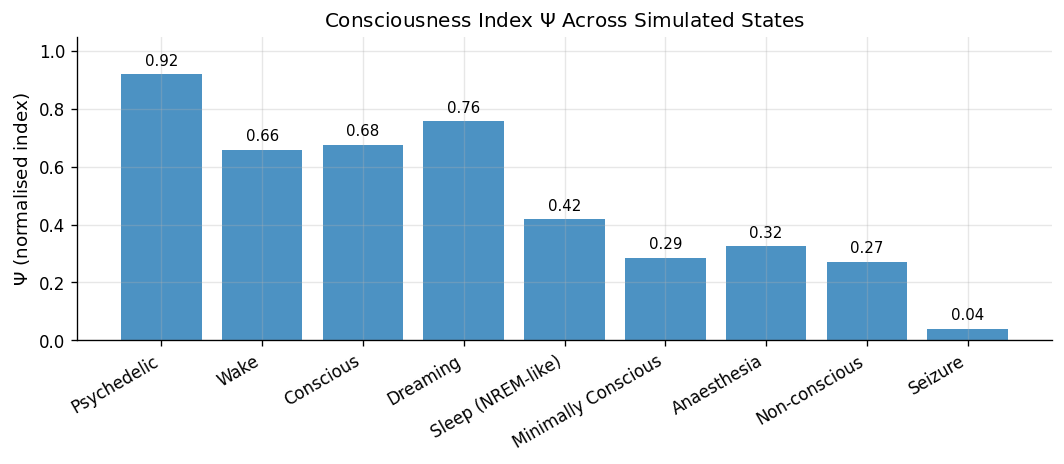

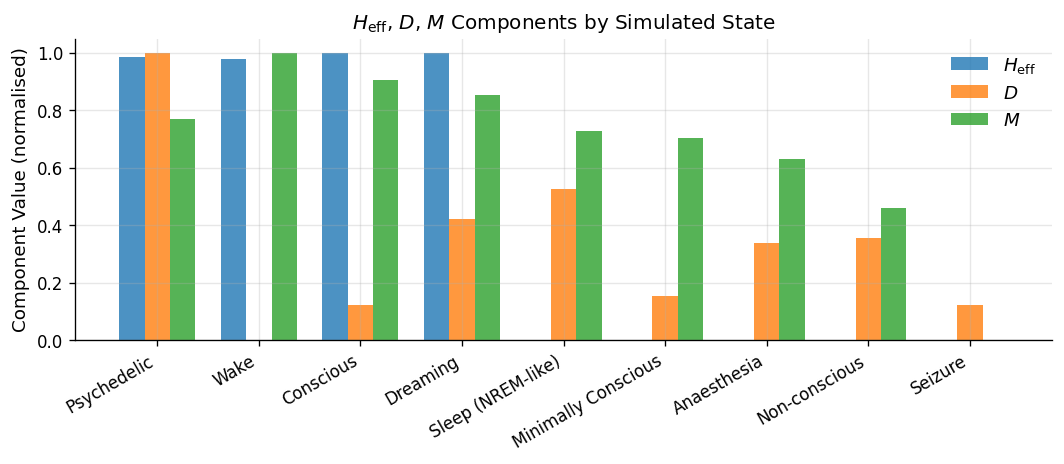

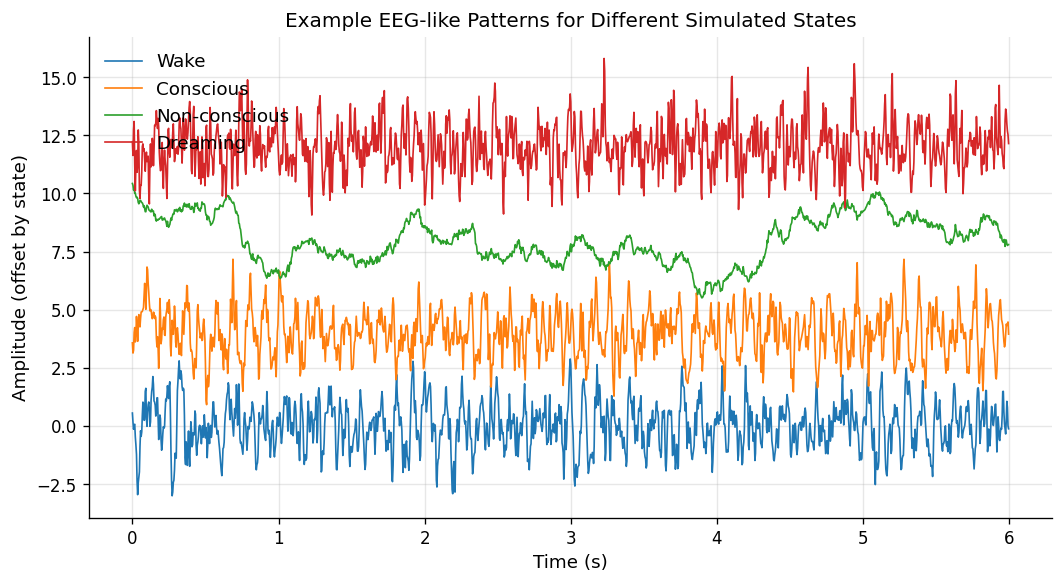


ANALYSIS COMPLETE


In [65]:

# ---------------------------------------------------------------------
# MAIN EXECUTION
# ---------------------------------------------------------------------
if __name__ == "__main__":
    # ===========================================================
    # 1. EEG-LIKE STATE SIMULATIONS AND PLOTS
    # ===========================================================
    print("=== SIGNAL VERIFICATION ===")
    test_states = ["wake", "conscious", "dreaming", "non_conscious"]

    for st in test_states:
        if st == "wake":
            X_test = simulate_state_fast(
                state="wake", n_channels=4, T=1000, fs=CFG["fs"]
            )
        else:
            X_test = globals()[f"simulate_{st}_state"](
                n_channels=4, T=1000, fs=CFG["fs"]
            )

        print(f"\n{st:>15}:")
        print(f"  Mean amplitude: {np.mean(np.abs(X_test)):.4f}")
        print(f"  Std deviation:  {np.std(X_test):.4f}")
        print(f"  RMS power:      {np.sqrt(np.mean(X_test**2)):.4f}")
        print(f"  Dynamic range:  {np.ptp(X_test):.4f}")

    print("\n" + "=" * 60)
    print("Running single-run consciousness state analysis...")
    print("=" * 60)

    all_states_to_simulate = [
        "wake",
        "sleep",
        "anesthesia",
        "seizure",
        "psychedelic",
        "conscious",
        "non_conscious",
        "minimally_conscious",
        "dreaming",
    ]

    results = []
    for st in all_states_to_simulate:
        print(f"  Processing {st}...")
        if st in ["wake", "sleep", "anesthesia", "seizure", "psychedelic"]:
            X = simulate_state_fast(
                state=st, n_channels=16, T=3000, fs=CFG["fs"]
            )
        elif st == "conscious":
            X = simulate_conscious_state(
                n_channels=16, T=3000, fs=CFG["fs"]
            )
        elif st == "non_conscious":
            X = simulate_non_conscious_state(
                n_channels=16, T=3000, fs=CFG["fs"]
            )
        elif st == "minimally_conscious":
            X = simulate_minimally_conscious_state(
                n_channels=16, T=3000, fs=CFG["fs"]
            )
        elif st == "dreaming":
            X = simulate_dreaming_state(
                n_channels=16, T=3000, fs=CFG["fs"]
            )
        else:
            raise ValueError("Unexpected state")

        met = compute_all_metrics(X, CFG["fs"])
        met["state"] = st
        results.append(met)

    df = pd.DataFrame(results)

    state_display_names = {
        "wake": "Wake",
        "sleep": "Sleep (NREM-like)",
        "anesthesia": "Anaesthesia",
        "seizure": "Seizure",
        "psychedelic": "Psychedelic",
        "conscious": "Conscious",
        "non_conscious": "Non-conscious",
        "minimally_conscious": "Minimally Conscious",
        "dreaming": "Dreaming",
    }
    df["state"] = df["state"].replace(state_display_names)

    # H transformation recalibrated to high-consciousness states
    high_conscious_states = ["Wake", "Conscious", "Psychedelic", "Dreaming"]
    H_opt = df[df["state"].isin(high_conscious_states)]["H"].mean()
    sigma = 0.12

    print(f"\nUsing H_opt = {H_opt:.3f}, sigma = {sigma:.3f} for H → H_eff mapping.")

    df["H_eff"] = np.exp(-((df["H"] - H_opt) ** 2) / (2 * sigma**2))

    # Normalise H_eff, D, M to [0,1] across all states
    for src_col, dst_col in [
        ("H_eff", "H_norm"),
        ("D", "D_norm"),
        ("M", "M_norm"),
    ]:
        v = df[src_col].values
        v_min, v_max = np.min(v), np.max(v)
        if v_max > v_min:
            df[dst_col] = (v - v_min) / (v_max - v_min)
        else:
            df[dst_col] = 0.0

    df["PSI"] = (df["H_norm"] + df["D_norm"] + df["M_norm"]) / 3.0

    print("\nRaw & normalised results (single-run per state):")
    print(df[["state", "H", "D", "M", "H_eff", "PSI"]].round(3))

    # ---- Plot 1: Ψ across states ----
    plot_order = [
        "Psychedelic",
        "Wake",
        "Conscious",
        "Dreaming",
        "Sleep (NREM-like)",
        "Minimally Conscious",
        "Anaesthesia",
        "Non-conscious",
        "Seizure",
    ]
    plot_order = [s for s in plot_order if s in df["state"].values]
    df_plot = df.set_index("state").loc[plot_order].reset_index()

    plt.figure(figsize=(9, 4))
    x = np.arange(len(df_plot))
    psi_vals = df_plot["PSI"].values

    plt.bar(x, psi_vals, alpha=0.8)
    plt.xticks(x, df_plot["state"], rotation=30, ha="right")
    plt.ylabel("$\\Psi$ (normalised index)")
    plt.title("Consciousness Index $\\Psi$ Across Simulated States")
    plt.grid(axis="y", alpha=0.3)

    for xi, val in zip(x, psi_vals):
        plt.text(xi, val + 0.02, f"{val:.2f}", ha="center", va="bottom", fontsize=9)

    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig("psi_states.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ---- Plot 2: H_norm, D_norm, M_norm ----
    plt.figure(figsize=(9, 4))
    width = 0.25
    x = np.arange(len(df_plot))

    for i, (comp, label) in enumerate(
        [("H_norm", "$H_\\mathrm{eff}$"), ("D_norm", "$D$"), ("M_norm", "$M$")]
    ):
        vals = df_plot[comp].values
        plt.bar(x + i * width, vals, width, alpha=0.8, label=label)

    plt.xticks(x + width, df_plot["state"], rotation=30, ha="right")
    plt.ylabel("Component Value (normalised)")
    plt.title("$H_\\mathrm{eff}$, $D$, $M$ Components by Simulated State")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig("psi_components.png", dpi=300, bbox_inches="tight")
    plt.show()


    # ---- Plot 3: Example time series ----
    plt.figure(figsize=(9, 5))
    example_states = ["Wake", "Conscious", "Non-conscious", "Dreaming"]
    T_example = 1500
    t_axis = np.arange(T_example) / CFG["fs"]
    offset = 4.0

    for i, st in enumerate(example_states):
        if st == "Wake":
            X_ex = simulate_state_fast(
                state="wake", n_channels=1, T=T_example, fs=CFG["fs"]
            )
        elif st == "Conscious":
            X_ex = simulate_conscious_state(
                n_channels=1, T=T_example, fs=CFG["fs"]
            )
        elif st == "Non-conscious":
            X_ex = simulate_non_conscious_state(
                n_channels=1, T=T_example, fs=CFG["fs"]
            )
        elif st == "Dreaming":
            X_ex = simulate_dreaming_state(
                n_channels=1, T=T_example, fs=CFG["fs"]
            )
        else:
            continue

        plt.plot(
            t_axis,
            X_ex[0] + i * offset,
            label=st,
            linewidth=1.0,
        )

    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (offset by state)")
    plt.title("Example EEG-like Patterns for Different Simulated States")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    print("\n" + "=" * 60)
    print("ANALYSIS COMPLETE")
    print("=" * 60)
